> **Recorded AWS execution — 20260920-003336.** This notebook preserves the original code and scientific outputs. It is an evidence snapshot, not a claim that a data-free clone can rerun the private workspace. Start with [the portfolio overview](00_portfolio_overview.ipynb); see [reproduction instructions](../docs/REPRODUCIBILITY.md) and [current status](../docs/STATUS.md).


# 23 · Organizer training reproduction — numerical failure analysis

**Status: the public three-epoch training reproduction is NOT validated.** The allocator gate passed, but all three full epochs recorded NaN detection loss and zero node recall. This notebook documents the failure and the recovered evidence; it does not report competitive performance.

## Experimental contract

Pinned organizer commit: `075fc5f5a52d11077f9dc2b074644618f26939e2`. Version 4 used 180 training and 19 validation videos, batch 16, two Tesla T4s, and expandable allocator segments. The 32-step gate and full training were separate, unseeded training processes. A finite gate is therefore not proof that the fresh full run will remain finite. Internal accuracy × recall is not the official competition metric.

In [1]:
from pathlib import Path
import json, warnings
import plotly.graph_objects as go
from IPython.display import Image, display
ROOT = Path('/home/sagemaker-user/biohub-cell-tracking-during-development')
OUT = ROOT / 'outputs/public_frontier_reproduction/organizer_training_reproduction/runs/v4/numerical_recovery'
analysis = json.loads((OUT / "evidence_analysis.json").read_text())
audit = json.loads((OUT / "tensor_audit.json").read_text())
assert analysis["epochs_loop_completed"] == 3
assert analysis["epochs_numerically_valid"] == 0
assert audit["status"] == "completed"
assert audit["tests"]["status"] == "passed"
def show_png(fig, label, height=500):
    fig.update_layout(width=940, height=height, margin=dict(l=90, r=30, t=90, b=100))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        png = fig.to_image(format="png", width=940, height=height, scale=1)
    assert len(png) > 1000
    display(Image(data=png))
    print(label, "PNG_BYTES", len(png))
print("TRAINING_REPRODUCTION_SUCCESS", False)
print("RAW_EPOCHS_EXECUTED", analysis["epochs_loop_completed"])
print("NUMERICALLY_VALID_EPOCHS", analysis["epochs_numerically_valid"])
print("CPU_REGRESSION_TESTS_PASSED", audit["tests"]["checks_passed"])


TRAINING_REPRODUCTION_SUCCESS False
RAW_EPOCHS_EXECUTED 3
NUMERICALLY_VALID_EPOCHS 0
CPU_REGRESSION_TESTS_PASSED 12


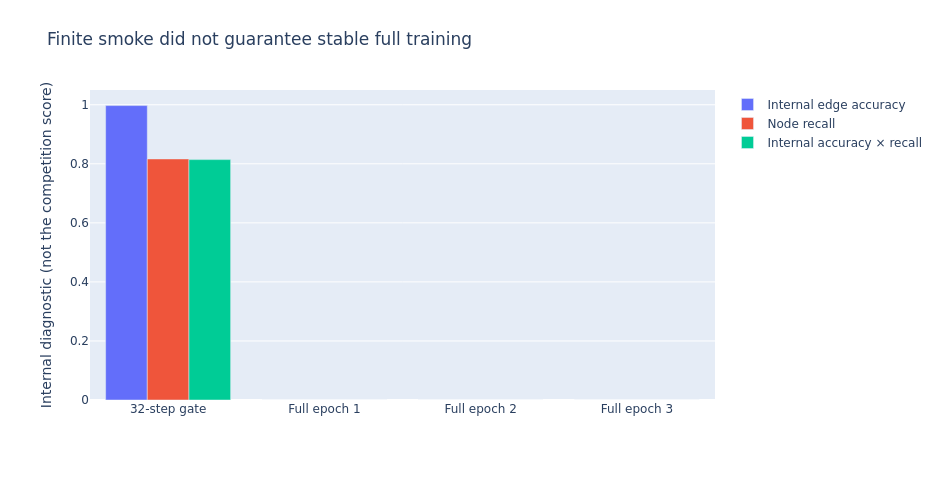

INTERNAL_DIAGNOSTICS PNG_BYTES 39221


In [2]:
rows = [analysis["gate"]] + analysis["full_epochs"]
labels = ["32-step gate"] + ["Full epoch " + str(r["epoch_number"]) for r in analysis["full_epochs"]]
fig = go.Figure()
for key, label in [("acc", "Internal edge accuracy"), ("recall", "Node recall"), ("best", "Internal accuracy × recall")]:
    fig.add_bar(x=labels, y=[r[key] for r in rows], name=label)
fig.update_layout(title="Finite smoke did not guarantee stable full training", barmode="group")
fig.update_yaxes(title="Internal diagnostic (not the competition score)", range=[0,1.05])
show_png(fig, "INTERNAL_DIAGNOSTICS")


## Why the failure was reported incorrectly

The old metric regex accepted only numeric characters, so it discarded rows containing `nan`. The epoch backup was triggered by that same regex. Three executed epochs were consequently reported as zero parsed epochs, and epoch snapshot receipts were missing. NaN is preserved as a raw token and null numeric value in this audit, never relabeled as zero loss.

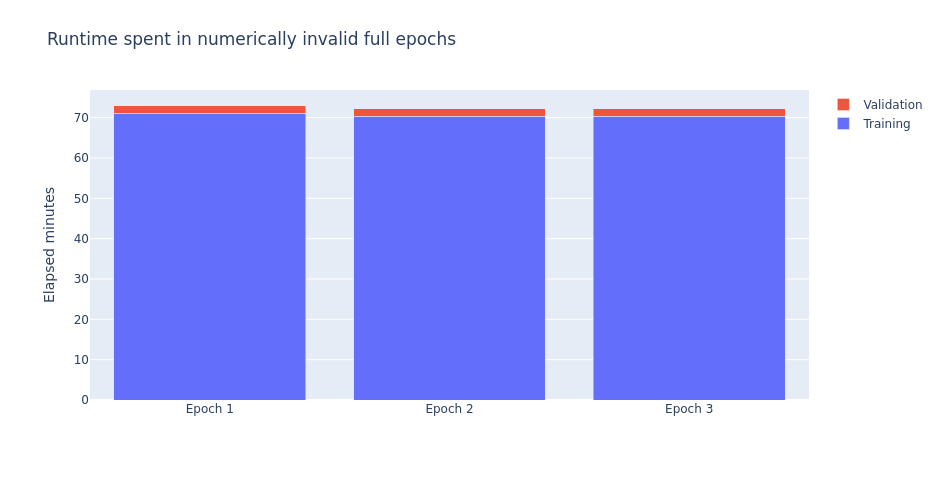

INVALID_EPOCH_RUNTIME PNG_BYTES 34246


In [3]:
fig = go.Figure()
for key, label in [("train_seconds", "Training"), ("test_seconds", "Validation")]:
    fig.add_bar(x=["Epoch " + str(r["epoch_number"]) for r in analysis["full_epochs"]],
                y=[r[key]/60 for r in analysis["full_epochs"]], name=label)
fig.update_layout(title="Runtime spent in numerically invalid full epochs", barmode="stack")
fig.update_yaxes(title="Elapsed minutes")
show_png(fig, "INVALID_EPOCH_RUNTIME")


## Mechanism test: empty key sets in cross-attention

The pinned model passes an all-padding key mask to multihead attention when a sample has no detections. A CPU synthetic test demonstrates nonfinite outputs and shared-parameter gradients even when the scalar loss uses only the nonempty sample. This demonstrates a reachable numerical defect, **not proof of the first failing historical GPU batch**. The candidate below skips the undefined attention update for empty key sets. Normal nonempty forward values and gradients are checked against the original implementation.

```python
    def forward(self, q, kv, kv_mask=None):
        if kv_mask is not None:
            if kv_mask.dtype != torch.bool:
                raise TypeError("kv_mask must be boolean")
            if tuple(kv_mask.shape) != tuple(kv.shape[:2]):
                raise ValueError("kv_mask shape must match key/value positions")
            has_keys = kv_mask.any(dim=1)
        else:
            has_keys = torch.full((q.shape[0],), kv.shape[1] > 0,
                                  device=q.device, dtype=torch.bool)
        if bool(has_keys.all()) and kv.shape[1] > 0:
            padding = ~kv_mask if kv_mask is not None else None
            attn_out, _ = self.cross_attn(
                self.norm1(q), self.norm1(kv), self.norm1(kv),
                key_padding_mask=padding,
            )
        else:
            attn_out = torch.zeros_like(q)
            index = has_keys.nonzero(as_tuple=True)[0]
            if index.numel():
                qs = q.index_select(0, index)
                ks = kv.index_select(0, index)
                padding = (~kv_mask.index_select(0, index)
                           if kv_mask is not None else None)
                values, _ = self.cross_attn(
                    self.norm1(qs), self.norm1(ks), self.norm1(ks),
                    key_padding_mask=padding,
                )
                attn_out = attn_out.index_copy(0, index, values)
        q = q + attn_out
        q = q + self.mlp(self.norm2(q))
        return q
```

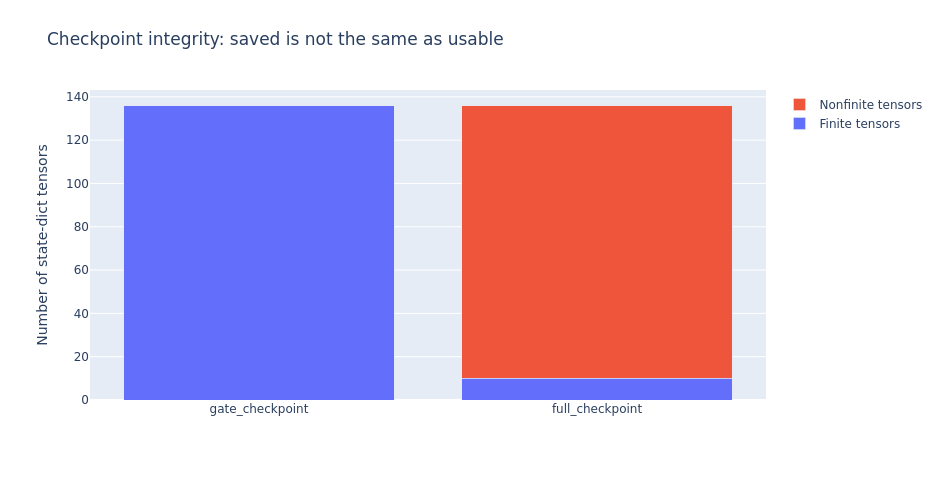

CHECKPOINT_INTEGRITY PNG_BYTES 36327


In [4]:
rows = audit["checkpoint_audits"]
fig = go.Figure()
fig.add_bar(x=[r["role"] for r in rows], y=[r["tensor_count"] - r["nonfinite_tensors"] for r in rows], name="Finite tensors")
fig.add_bar(x=[r["role"] for r in rows], y=[r["nonfinite_tensors"] for r in rows], name="Nonfinite tensors")
fig.update_layout(title="Checkpoint integrity: saved is not the same as usable", barmode="stack")
fig.update_yaxes(title="Number of state-dict tensors")
show_png(fig, "CHECKPOINT_INTEGRITY")


## Decision and next bounded experiment

Keep the hash-verified finite gate weights. Retain the failed full-run checkpoint separately as forensic evidence. Do not call this an optimizer-state resume: the old public checkpoints contain weights only. The next GPU test must check inputs, loss, gradients and updated parameters for nonfinite values at each step, save the last finite model/optimizer/RNG state, record sample/window identifiers, and stop on the first defect. No automatic three-epoch promotion follows from these CPU tests. The reference source is unchanged; the candidate is stored only as a research artifact.

In [5]:
for row in audit["tests"]["checks"]:
    print(row["name"], "PASS" if row["passed"] else "FAIL")
print("HISTORICAL_FIRST_BAD_BATCH_KNOWN", False)
print("HISTORICAL_TRIGGER_CONFIRMED", False)
print("EXACT_OPTIMIZER_RESUME_AVAILABLE", False)
print("NEXT: bounded real-data finite-value replay; no three-epoch rerun authorized by this audit")
print("NOTEBOOK23_NUMERICAL_AUDIT_COMPLETE")


pinned_empty_key_failure_reproduced PASS
guarded_mixed_empty_keys_finite_forward_backward PASS
guarded_all_empty_keys_finite_forward_backward PASS
guarded_partly_padded_finite_forward_backward PASS
nonempty_output_parity PASS
nonempty_gradient_parity PASS
parameter_schema_unchanged PASS
zero_length_key_tensor_finite PASS
full_transformer_empty_source_finite PASS
full_transformer_empty_target_finite PASS
full_transformer_both_empty_finite PASS
nonfinite_gradient_rejected_before_optimizer PASS
HISTORICAL_FIRST_BAD_BATCH_KNOWN False
HISTORICAL_TRIGGER_CONFIRMED False
EXACT_OPTIMIZER_RESUME_AVAILABLE False
NEXT: bounded real-data finite-value replay; no three-epoch rerun authorized by this audit
NOTEBOOK23_NUMERICAL_AUDIT_COMPLETE
